# EDA — 평가 케이스·기준값 리포트 탐색 분석

> 작성일: 2026-10-01 · 요약 보고서: [docs/EDA_REPORT.md](../docs/EDA_REPORT.md)

**재실행 조건**: LLM 호출 없음. 입력은 레포에 커밋된 파일만 쓴다 —
`eval/cases/*.json`(42건), git이 추적하는 `eval/results/` 기준값 리포트(10개),
그리고 로컬에 있을 때만 `logs/audit.jsonl`(없으면 해당 절은 건너뛴다).
실행 준비: `pip install -r requirements-eda.txt` (메인 의존성에 더해
matplotlib·nbformat·nbclient·ipykernel).

분석 범위(합의): **A** 평가 케이스 42건 분포 + **B** 기준값 리포트 이력 중심,
**C** 감사 로그는 구조 시연 1절(개인정보 보호 — 집계값만, 원문 행 미출력),
**E** 부록(개선 실험 판정·경계 프로브). 비용 실측(D)은 제외 — 문서 기록 수치만
인용한다 ([REPORT.md](../REPORT.md) 7.4).

## 0. 데이터 수집·정제 과정

이 데이터는 스크래핑이 아니라 **실측으로 만든** 것이다. 과정 자체가 품질 통제다.

1. **기대값 고정 방식** — 후보 요구를 먼저 적고 → Builder에 실제로 던지고 →
   어긋난 것만 고정한다 (추측으로 기대값을 적지 않는다). 이 절차로 잡은 것 중
   하나는 과잉 선택을 노렸는데 정반대(과소 선택)가 나온 케이스였다.
2. **확장 이력**: 9건 → 12건(보안 결함 1건 적발) → 21건(평가 스위트 자체 결함
   4건 발견) → 27건(수정 revise 경로 개봉) → **42건**(직무 프로필 infra 7 ·
   dev 8 추가, 기존 27건 무수정 — `profile` 필드 기본값 호환).
3. **케이스 결함 수정 사례** — 케이스도 채점 대상이다. `no_tools_needed`의
   forbid 누락(심판이 2/5로 잡음), `python_script_fix_honesty`의 forbid
   누락(rubric 전제 붕괴, 1/5), `adfs_runbook_research`의 두-동사 문구(팀 판단
   경계 유발). 수정 사유는 케이스 파일의 `_note` 필드에 남긴다.
4. **흔들리는 입력의 분리** — Builder가 간헐적으로 다른 답을 내는 경계 문구는
   세트에 넣지 않고 `eval/boundary.py` 프로브로 분리해 **통과/실패 대신
   빈도**로 관리한다 (기준값 오염 방지).
5. **스키마 검증** — `EvalCase`(Pydantic)가 id 패턴·profile 허용값·revise_base
   스펙 유효성·중복 id를 **로드 시점에** 검증한다. 깨진 케이스는 LLM 호출 전에
   실패한다 (이미 지불한 호출 결과가 유실되는 사고의 재발 방지).

In [1]:
# 1. 셋업 — 경로·한글 폰트(맑은 고딕, 없으면 폴백)
import sys, json, re, subprocess
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT))

OUT = PROJECT / "docs" / "images" / "eda"
OUT.mkdir(parents=True, exist_ok=True)

_available = {f.name for f in fm.fontManager.ttflist}
for _cand in ["Malgun Gothic", "NanumGothic", "Gulim", "Batang"]:
    if _cand in _available:
        plt.rcParams["font.family"] = _cand
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
print("폰트:", plt.rcParams["font.family"], "| 프로젝트:", PROJECT.name)

폰트: ['Malgun Gothic'] | 프로젝트: deep-builder-agent


In [2]:
# 2. A — 평가 케이스 42건 로드 (레포 커밋본, 스키마 검증 통과가 전제)
from eval.dataset import load_cases

cases = load_cases()
df = pd.DataFrame(
    {
        "id": c.id,
        "profile": c.profile,
        "expect_tools": tuple(c.expect_tools),
        "forbid_tools": tuple(c.forbid_tools),
        "n_expect": len(c.expect_tools),
        "n_forbid": len(c.forbid_tools),
        "expect_team": c.expect_team,
        "is_revise": c.revise_base is not None,
        "req_len": len(c.request),
    }
    for c in cases
)
print(f"케이스 {len(df)}건 | 세트: {dict(df.profile.value_counts())}")
print(f"팀 기대 {int(df.expect_team.sum())}건 · 수정(revise) 경로 {int(df.is_revise.sum())}건")
df.describe(include="all").loc[["count", "mean", "min", "max"], ["n_expect", "n_forbid", "req_len"]]

케이스 42건 | 세트: {'common': np.int64(27), 'dev': np.int64(8), 'infra': np.int64(7)}
팀 기대 5건 · 수정(revise) 경로 2건


,n_expect,n_forbid,req_len
count,42.000000,42.000000,42.000000
mean,0.904762,1.738095,62.261905
min,0.000000,0.000000,22.000000
max,4.000000,6.000000,315.000000


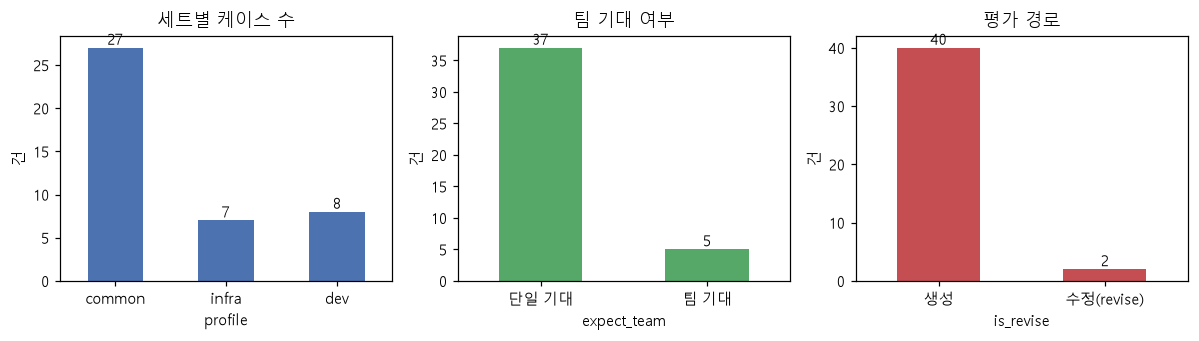

In [3]:
# 3. A — 세트·팀 기대·경로 분포
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
order = ["common", "infra", "dev"]
df.profile.value_counts().reindex(order).plot.bar(ax=axes[0], color="#4c72b0", rot=0)
axes[0].set_title("세트별 케이스 수")
df.expect_team.map({True: "팀 기대", False: "단일 기대"}).value_counts().plot.bar(
    ax=axes[1], color="#55a868", rot=0
)
axes[1].set_title("팀 기대 여부")
df.is_revise.map({True: "수정(revise)", False: "생성"}).value_counts().plot.bar(
    ax=axes[2], color="#c44e52", rot=0
)
axes[2].set_title("평가 경로")
for ax in axes:
    ax.bar_label(ax.containers[0])
    ax.set_ylabel("건")
fig.tight_layout()
fig.savefig(OUT / "case_overview.png", bbox_inches="tight")
plt.show()

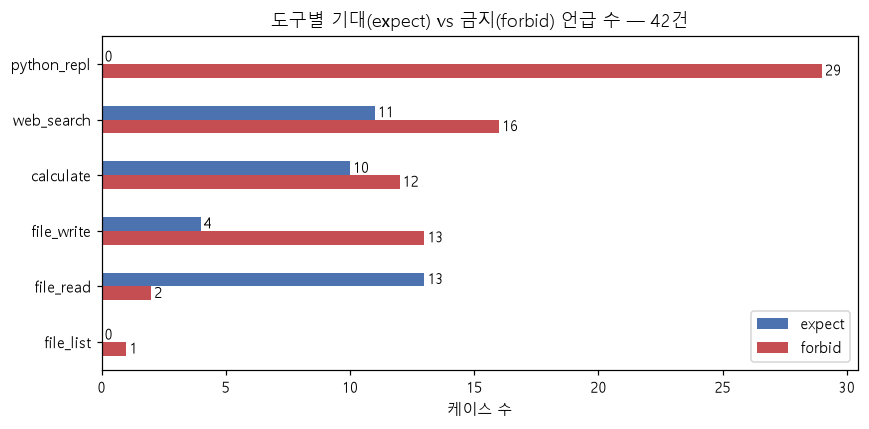

python_repl: expect 0건 / forbid 29건 — 스위트에서 가장 많이 '금지'되는 도구다 (임의 코드 실행 과잉 부여 감시)


In [4]:
# 4. A — 도구별 expect/forbid 빈도: 스위트가 무엇을 요구하고 무엇을 막는가
expect_cnt = Counter(t for ts in df.expect_tools for t in ts)
forbid_cnt = Counter(t for ts in df.forbid_tools for t in ts)
tools = sorted(set(expect_cnt) | set(forbid_cnt), key=lambda t: -(expect_cnt[t] + forbid_cnt[t]))
tool_df = pd.DataFrame(
    {"expect": [expect_cnt[t] for t in tools], "forbid": [forbid_cnt[t] for t in tools]},
    index=tools,
)
ax = tool_df.plot.barh(figsize=(8, 4), color={"expect": "#4c72b0", "forbid": "#c44e52"})
ax.invert_yaxis()
ax.set_title("도구별 기대(expect) vs 금지(forbid) 언급 수 — 42건")
ax.set_xlabel("케이스 수")
for c in ax.containers:
    ax.bar_label(c, padding=2)
plt.tight_layout()
plt.savefig(OUT / "tool_mentions.png", bbox_inches="tight")
plt.show()
print(
    f"python_repl: expect {expect_cnt['python_repl']}건 / forbid {forbid_cnt['python_repl']}건 "
    "— 스위트에서 가장 많이 '금지'되는 도구다 (임의 코드 실행 과잉 부여 감시)"
)

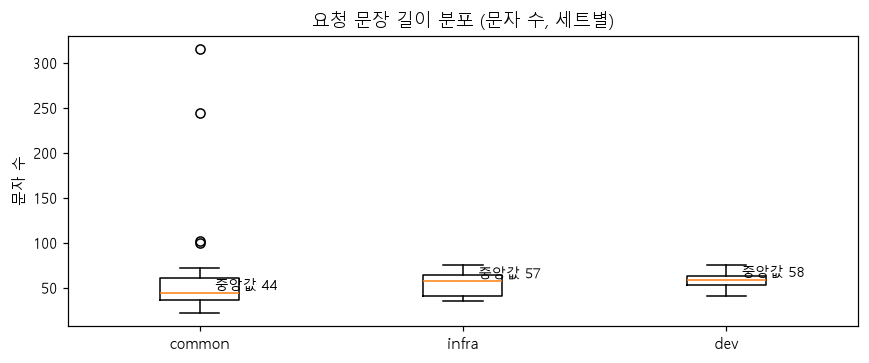

In [5]:
# 5. A — 요청 문장 길이 (세트별): 프로필 케이스가 더 길고 구체적인가?
fig, ax = plt.subplots(figsize=(8, 3.4))
data = [df.loc[df.profile == p, "req_len"] for p in order]
ax.boxplot(data, tick_labels=order)
ax.set_title("요청 문장 길이 분포 (문자 수, 세트별)")
ax.set_ylabel("문자 수")
for i, s in enumerate(data, 1):
    ax.annotate(f"중앙값 {int(s.median())}", (i, s.median()), textcoords="offset points",
                xytext=(10, 2), fontsize=9)
plt.tight_layout()
plt.savefig(OUT / "request_length.png", bbox_inches="tight")
plt.show()

In [6]:
# 6. B — git이 추적하는 기준값 리포트 파싱 (clone에서도 동일하게 재실행된다)
tracked = subprocess.run(
    ["git", "ls-files", "eval/results"], cwd=PROJECT, capture_output=True, text=True
).stdout.split()

HEAD_RE = re.compile(r"(?P<p>\d+)/(?P<t>\d+) 통과.*?(?:평균 (?P<m>[\d.]+)점)?$")
CASE_RE = re.compile(r"^\[(?P<s>PASS|FAIL)\] (?P<id>\S+)")
JUDGE_RE = re.compile(r"judge (?P<score>\d)/5 — (?P<reason>.+)$")
NAME_RE = re.compile(r"(?P<d>\d{4}-\d{2}-\d{2})_(?P<hms>\d{6})(?:_(?P<set>\w+))?\.txt$")

rows, case_rows = [], []
for rel in tracked:
    path = PROJECT / rel
    name = NAME_RE.search(path.name)
    lines = path.read_text(encoding="utf-8").splitlines()
    head = HEAD_RE.search(lines[0])
    eval_set = name["set"] or "common"  # 세트 접미사 도입(Phase 9) 전 리포트는 공통 실행이었다
    stamp = f"{name['d']} {name['hms'][:2]}:{name['hms'][2:4]}"
    rows.append({
        "stamp": stamp, "set": eval_set,
        "passed": int(head["p"]), "total": int(head["t"]),
        "mean": float(head["m"]) if head["m"] else None,
        "file": path.name,
    })
    current = None
    for line in lines[1:]:
        if m := CASE_RE.match(line):
            current = {"stamp": stamp, "set": eval_set, "id": m["id"],
                       "passed": m["s"] == "PASS", "score": None, "reason": ""}
            case_rows.append(current)
        elif current and (j := JUDGE_RE.search(line)):
            current["score"] = int(j["score"])
            current["reason"] = j["reason"]

reports = pd.DataFrame(rows).sort_values(["set", "stamp"]).reset_index(drop=True)
case_df = pd.DataFrame(case_rows)
reports["rate"] = reports.passed / reports.total
print(f"기준값 리포트 {len(reports)}개, 케이스 행 {len(case_df)}건 (심판 점수 있는 행 {case_df.score.notna().sum()}건)")
reports[["stamp", "set", "passed", "total", "mean", "file"]]

기준값 리포트 10개, 케이스 행 153건 (심판 점수 있는 행 151건)


,stamp,set,passed,total,mean,file
0,2026-09-30 23:26,common,27,27,4.93,2026-09-30_232655.txt
1,2026-10-01 10:13,common,27,27,5.00,2026-10-01_101343.txt
2,2026-10-01 12:58,common,27,27,4.96,2026-10-01_125820_common.txt
3,2026-10-01 13:41,common,27,27,4.96,2026-10-01_134146_common.txt
4,2026-10-01 11:37,dev,8,8,5.00,2026-10-01_113703_dev.txt
5,2026-10-01 13:03,dev,6,8,5.00,2026-10-01_130346_dev.txt
6,2026-10-01 13:47,dev,8,8,4.88,2026-10-01_134722_dev.txt
7,2026-10-01 11:40,infra,7,7,5.00,2026-10-01_114021_infra.txt
8,2026-10-01 13:00,infra,7,7,5.00,2026-10-01_130056_infra.txt
9,2026-10-01 13:44,infra,7,7,5.00,2026-10-01_134433_infra.txt


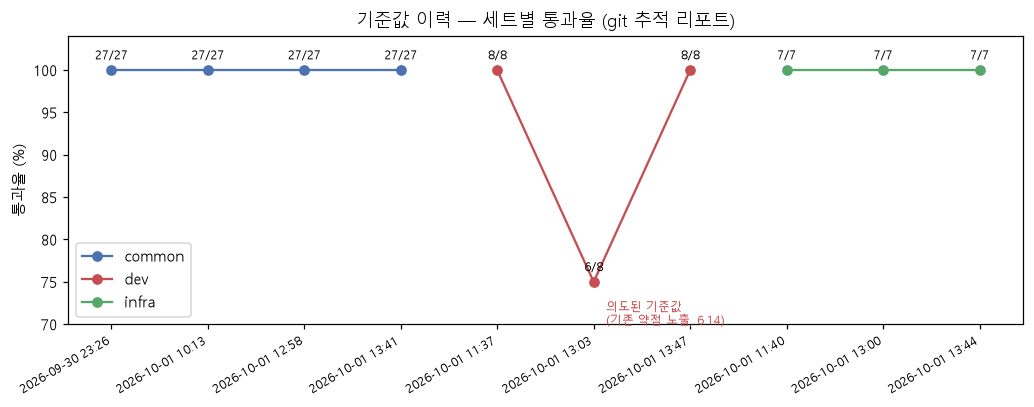

In [7]:
# 7. B — 기준값 이력 추이 (세트별 통과율)
fig, ax = plt.subplots(figsize=(9.5, 3.8))
colors = {"common": "#4c72b0", "infra": "#55a868", "dev": "#c44e52"}
for eval_set, grp in reports.groupby("set"):
    ax.plot(grp.stamp, grp.rate * 100, marker="o", label=eval_set, color=colors[eval_set])
    for _, r in grp.iterrows():
        ax.annotate(f"{r.passed}/{r.total}", (r.stamp, r.rate * 100),
                    textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
low = reports[reports.rate < 1]
for _, r in low.iterrows():
    ax.annotate("의도된 기준값\n(기존 약점 노출, 6.14)", (r.stamp, r.rate * 100),
                textcoords="offset points", xytext=(8, -28), fontsize=8, color="#c44e52")
ax.set_ylim(70, 104)
ax.set_ylabel("통과율 (%)")
ax.set_title("기준값 이력 — 세트별 통과율 (git 추적 리포트)")
ax.legend()
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "baseline_history.png", bbox_inches="tight")
plt.show()

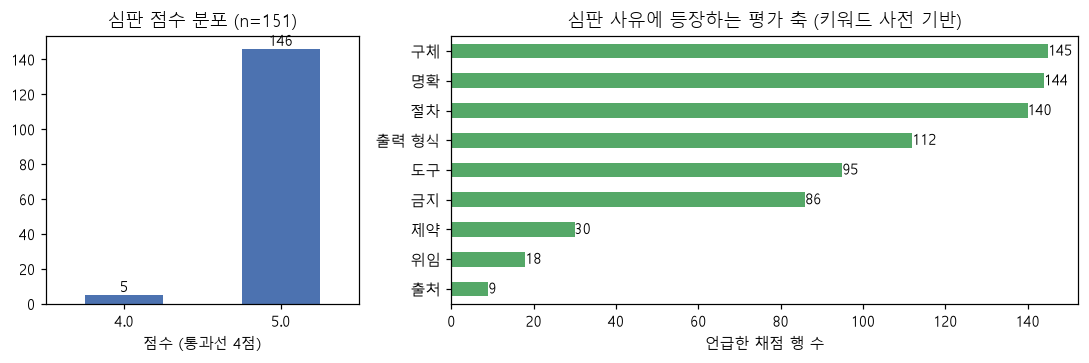

4점(통과하되 감점) 5건:
  - read_before_analyze (2026-09-30 23:26, common): 파일 읽기 절차가 구체적이고, 감정 분석 기준(주요 감정, 원인, 흐름, 요약)이 명확하며, 불필요한 도구를 추가하지 않았다. 다만 감정 판단 ...
  - revise_adds_a_tool (2026-09-30 23:26, common): 요구한 저장 기능이 명확히 추가되었고 기존 기능(검색, 3줄 요약, 결과 없을 때 처리)도 보존되었으며, 도구 사용 시점이 절차에 명시되었다. ...
  - revise_adds_a_tool (2026-10-01 12:58, common): 요구의 저장 기능이 절차에 추가되었고 기존 기능(검색, 3줄 요약, 결과 없을 때 처리)도 보존되었다. 다만 파일 이름 형식이나 저장 위치 구체...
  - jargon_heavy_finance (2026-10-01 13:41, common): 수익률→변동성→샤프 비율→상관계수 계산 절차가 구체적이고, calculate 도구로 모든 수식 계산을 명시했으며, 실시간 시세 검색을 끌어오지 ...
  - python_traceback_read (2026-10-01 13:47, dev): traceback 마지막 예외와 호출 스택을 근거로 원인을 분석하는 절차가 명확하고, 동기화 스크립트 특성상 자주 발생하는 원인들(네트워크, 파...


In [8]:
# 8. B — 심판 점수 분포와 4점의 이유
scored = case_df.dropna(subset=["score"])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), width_ratios=[1, 2])
scored.score.value_counts().sort_index().plot.bar(ax=axes[0], color="#4c72b0", rot=0)
axes[0].bar_label(axes[0].containers[0])
axes[0].set_title(f"심판 점수 분포 (n={len(scored)})")
axes[0].set_xlabel("점수 (통과선 4점)")

KEYWORDS = ["절차", "출력 형식", "금지", "도구", "구체", "명확", "출처", "위임", "제약"]
kw = pd.Series({k: scored.reason.str.contains(k).sum() for k in KEYWORDS}).sort_values()
kw.plot.barh(ax=axes[1], color="#55a868")
axes[1].bar_label(axes[1].containers[0])
axes[1].set_title("심판 사유에 등장하는 평가 축 (키워드 사전 기반)")
axes[1].set_xlabel("언급한 채점 행 수")
plt.tight_layout()
plt.savefig(OUT / "judge_scores.png", bbox_inches="tight")
plt.show()

four = scored[scored.score == 4]
print(f"4점(통과하되 감점) {len(four)}건:")
for _, r in four.iterrows():
    print(f"  - {r.id} ({r.stamp}, {r['set']}): {r.reason[:80]}...")

## 9. C — 감사 로그 구조 시연 (로컬 전용, 집계값만)

`logs/audit.jsonl`은 gitignore 대상이라 clone에는 없다 — 아래 셀은 파일이 있을
때만 집계를 보여준다. **개인정보 보호**: principal에는 검증된 이메일이 들어갈 수
있으므로 **원문 행은 출력하지 않고** 필드 구조와 집계값만 싣는다.

감사 레코드 50행 | 필드: ['action', 'decision', 'detail', 'pid', 'principal', 'resource', 'role', 'timestamp']
주체 종류 4개 (이름은 출력하지 않음 — 개인정보 보호)

행위 × 판정 집계:
decision      allow
action             
create_agent      5
revise_agent      2
run_agent        32
view             11


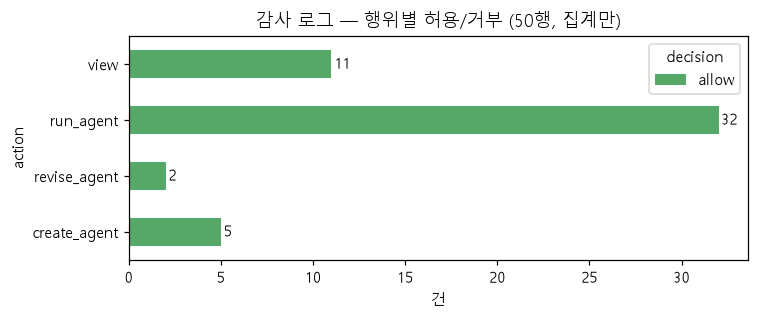

In [9]:
audit_path = PROJECT / "logs" / "audit.jsonl"
if not audit_path.exists():
    print("logs/audit.jsonl 없음 (clone 상태) — 구조 시연 절은 건너뛴다")
else:
    records = [json.loads(line) for line in audit_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    adf = pd.DataFrame(records)
    print(f"감사 레코드 {len(adf)}행 | 필드: {sorted(adf.columns)}")
    print(f"주체 종류 {adf.principal.nunique()}개 (이름은 출력하지 않음 — 개인정보 보호)")
    pivot = adf.pivot_table(index="action", columns="decision", aggfunc="size", fill_value=0)
    print("\n행위 × 판정 집계:")
    print(pivot.to_string())
    ax = pivot.plot.barh(figsize=(7, 3), color={"allow": "#55a868", "deny": "#c44e52"})
    ax.set_title(f"감사 로그 — 행위별 허용/거부 ({len(adf)}행, 집계만)")
    ax.set_xlabel("건")
    for c in ax.containers:
        ax.bar_label(c, padding=2)
    plt.tight_layout()
    plt.savefig(OUT / "audit_summary.png", bbox_inches="tight")
    plt.show()

## 10. E — 부록: 개선 실험 판정·경계 프로브

상세는 [docs/EVAL_COMPARISON.md](../docs/EVAL_COMPARISON.md). 여기서는 판정과
표본(근거 강도)만 집계한다.

In [10]:
experiments = pd.DataFrame([
    (1, "도구·팀 판단 프롬프트 수정", "개선", "전후 각 1회", True),
    (2, "Builder 질문 단계 제거", "개선", "수정 후 2회 연속", False),
    (3, "할 수 없는 일 규칙", "개선", "수정 후 2회 연속", False),
    (4, "calculate 분리", "개선", "전후 각 1회", True),
    (5, "팀 판단 모순 1차 제거", "개선", "재실행 1회 + 케이스 3회 반복", False),
    (6, "심판 입력 보강", "개선", "재채점 1회", True),
    (7, "calculate 대안 힌트", "개선", "전 1회 · 후 2회", False),
    (8, "팀 판단 모순 2차 제거", "미검출", "전 8회 · 후 5회", False),
    (9, "python_repl 범위 명시", "개선", "전 8회 · 후 5회 (+보조 5회)", False),
], columns=["사례", "대상", "판정", "표본", "단일실행_근거약함"])
print(experiments.판정.value_counts().to_string())
print(f"단일 실행 판정(근거 약함) {int(experiments.단일실행_근거약함.sum())}건 — 반복 측정 관행은 6.11 이후")

from eval.boundary import BOUNDARY_PROBES
print(f"\n경계 프로브 {len(BOUNDARY_PROBES)}종 (세트 밖 — 팀 생성 빈도 관리):")
for p in BOUNDARY_PROBES:
    print(f"  - {p.id}: {p.observed[:70]}...")
experiments

판정
개선     8
미검출    1
단일 실행 판정(근거 약함) 3건 — 반복 측정 관행은 6.11 이후

경계 프로브 4종 (세트 밖 — 팀 생성 빈도 관리):
  - research_then_summarize: 2026-10-01: 수정 전 합산 8회 중 2회 팀(오전 발견 3회 중 2회 + 대칭 측정 5회 중 0회) → 중간본(예시 ...
  - read_log_then_organize: 2026-10-01: 수정 전 0/5 · 중간본 0/5 · 최종본 0/5...
  - search_then_tabulate: 2026-10-01: 수정 전 0/5 · 중간본 0/5 · 최종본 0/5...
  - read_minutes_then_todos: 2026-10-01: 수정 전 0/5 · 중간본 0/5 · 최종본 0/5...


,사례,대상,판정,표본,단일실행_근거약함
0,1,도구·팀 판단 프롬프트 수정,개선,전후 각 1회,True
1,2,Builder 질문 단계 제거,개선,수정 후 2회 연속,False
2,3,할 수 없는 일 규칙,개선,수정 후 2회 연속,False
3,4,calculate 분리,개선,전후 각 1회,True
4,5,팀 판단 모순 1차 제거,개선,재실행 1회 + 케이스 3회 반복,False
5,6,심판 입력 보강,개선,재채점 1회,True
6,7,calculate 대안 힌트,개선,전 1회 · 후 2회,False
7,8,팀 판단 모순 2차 제거,미검출,전 8회 · 후 5회,False
8,9,python_repl 범위 명시,개선,전 8회 · 후 5회 (+보조 5회),False


## 핵심 발견 요약

해석과 차트는 [docs/EDA_REPORT.md](../docs/EDA_REPORT.md)에 정리한다. 수치 요약:
위 셀들의 출력이 단일 진실 원천이다 — 보고서의 숫자가 노트북과 어긋나면
노트북을 다시 실행해 보고서를 고친다.